In [1]:
# Separate cell for the imports

import ast
import pandas as pd
import numpy as np
import json
import os
import joblib
import re
import matplotlib.pyplot as plt
import emoji
from fpdf import FPDF
from gensim.models import FastText
from fpdf.enums import XPos, YPos
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.multioutput import MultiOutputClassifier

C:\Users\20231776\.conda\envs\GA2_Geopandas_Spec\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
def log_report(classifier_name, col, report_str):
    file_path = "classification_results.json"
    
    # Load existing file if it exists, otherwise start fresh
    if os.path.exists(file_path):
        with open(file_path, "r", encoding="utf-8") as f:
            try:
                data = json.load(f)
            except:
                data = {}
    else:
        data = {}
        
    # Structure data by model name, then by target attribute column
    if classifier_name not in data:
        data[classifier_name] = {}
    data[classifier_name][col] = report_str
    
    # Write back out to file
    with open(file_path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4)

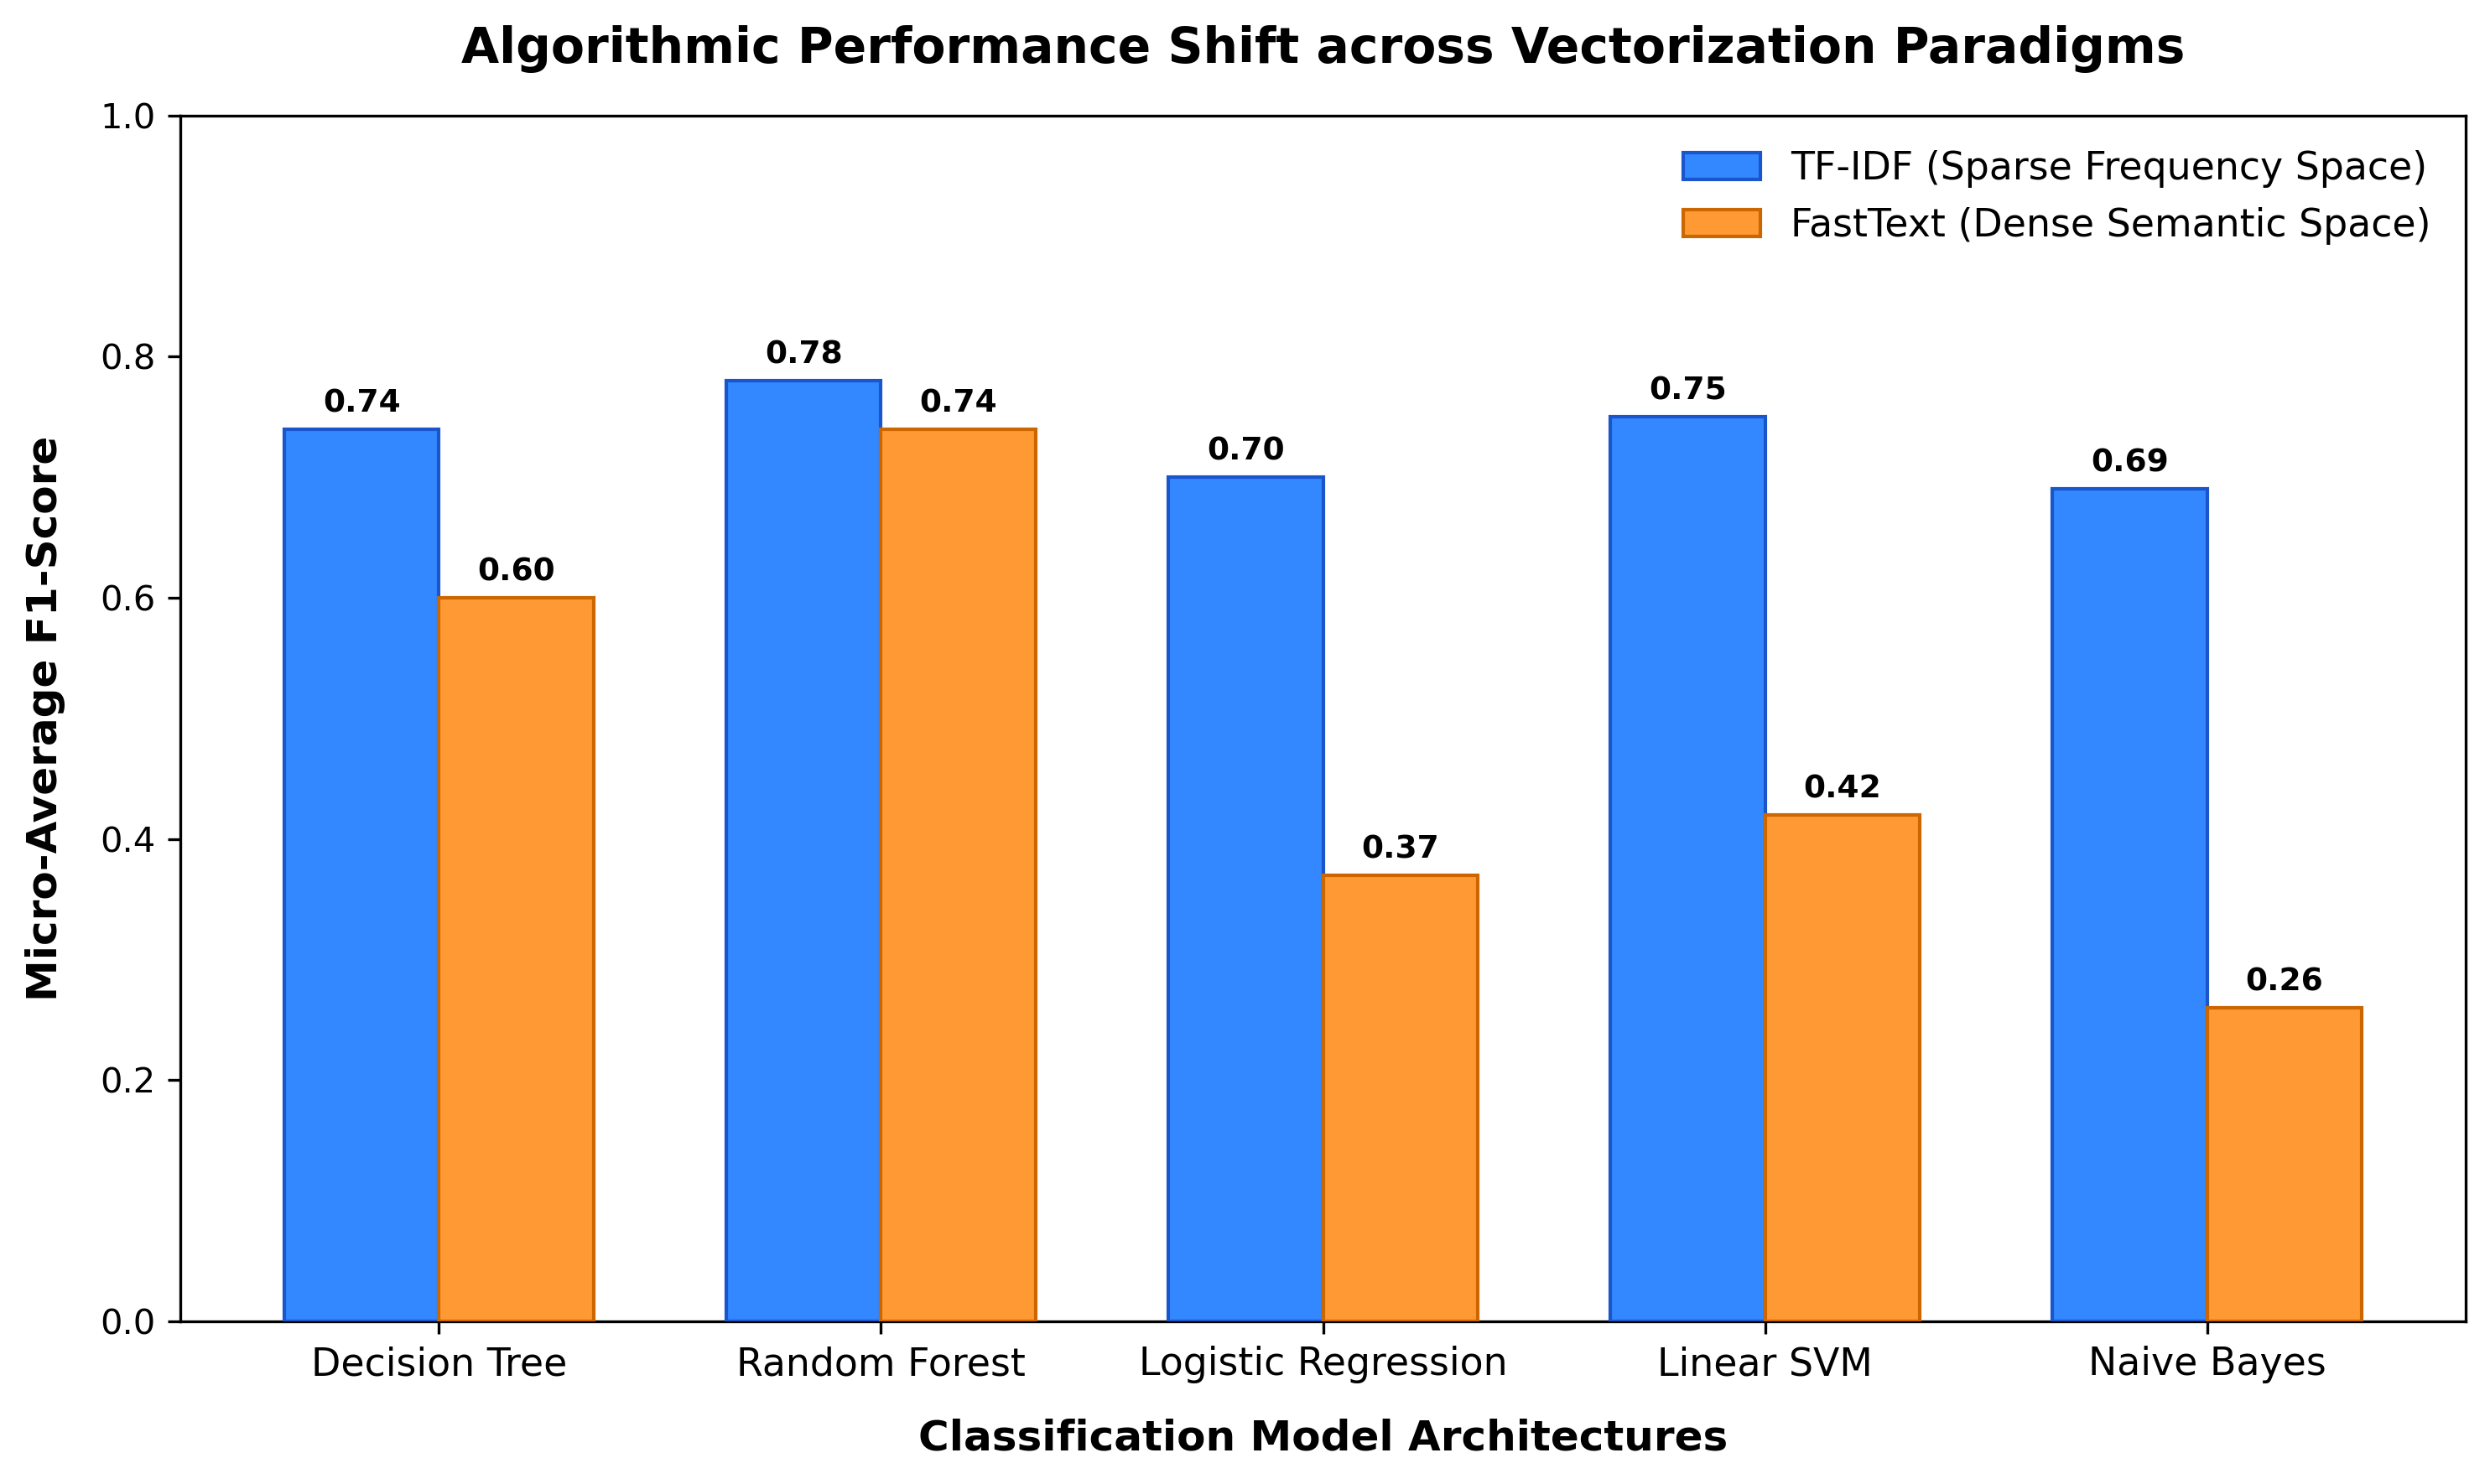

In [3]:
# Set up the plot style and size
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

classifiers = [
    'Decision Tree', 
    'Random Forest', 
    'Logistic Regression', 
    'Linear SVM', 
    'Naive Bayes'
]
tf_idf_scores = [0.74, 0.78, 0.70, 0.75, 0.69]
fasttext_scores = [0.60, 0.74, 0.37, 0.42, 0.26]

# Set bar positions and widths
x = np.arange(len(classifiers))  
width = 0.35  

# Plot the bars side by side
rects1 = ax.bar(x - width/2, tf_idf_scores, width, label='TF-IDF (Sparse Frequency Space)', color='#3388ff', edgecolor='#1a55cc', zorder=3)
rects2 = ax.bar(x + width/2, fasttext_scores, width, label='FastText (Dense Semantic Space)', color='#ff9933', edgecolor='#cc6600', zorder=3)

ax.set_ylabel('Micro-Average F1-Score', fontsize=12, fontweight='bold', labelpad=10)
ax.set_xlabel('Classification Model Architectures', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Algorithmic Performance Shift across Vectorization Paradigms', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(classifiers, fontsize=11)
ax.set_ylim(0, 1.0)

ax.legend(loc='upper right', fontsize=11, frameon=True, facecolor='white', edgecolor='none')

# Function to add values on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()

# Save and show the final image
plt.savefig('classifier_performance_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
# Loads data from the file
try:
    df = pd.read_csv("labelled-messages.csv")
except FileNotFoundError:
    print(f"Error: File not found at {downloads_path}. Please check the filename.")

In [5]:
def extract_attributes(state_str):
    # Removes missing or null data
    if pd.isna(state_str):
        return pd.Series([None]*8)
    try:
        # Loads the JSON string
        data = json.loads(state_str)
        
        # Pull level 1 data
        category = data.get('level1', {}).get('category', [])
        
        # Find the supply mode
        supply_dict = data.get('level3', {}).get('supplyMode', {})
        supply_mode = next((k.upper() for k, v in supply_dict.items() if v is True and k != 'enabled'), 'UNKNOWN')
        
        tool_type = [k for k, v in data.get('level3', {}).get('tool', {}).get('types', {}).items() if v is True]
        difi_infrastructure = [k for k, v in data.get('level3', {}).get('digitalInfrastructure', {}).get('types', {}).items() if v is True]
        data_types = [k for k, v in data.get('level3', {}).get('data', {}).get('types', {}).items() if v is True]
        
        # Get active account types
        account_types = [k for k, v in data.get('level4', {}).get('account', {}).get('types', {}).items() if v is True]
        
        # gets main capabilities, handles comma-separated values
        cap_data = data.get('level4', {}).get('capability', {})
        main_capability = cap_data.get('mainCapability', None)
        cap_data = data.get('level4', {}).get('capability', {})
        raw_main = cap_data.get('mainCapability', "")
        
        if isinstance(raw_main, str) and "," in raw_main:
            main_capability = [i.strip() for i in raw_main.split(",")]
        elif raw_main:
            main_capability = [raw_main]
        else:
            main_capability = []

        # Gets extra capabilities
        other_capability = [k for k, v in cap_data.get('auxiliary', {}).items() if v is True]     
        
        # Returns all extracted data as a row
        return pd.Series([
            category, supply_mode, tool_type, difi_infrastructure, 
            data_types, account_types, main_capability, other_capability
        ])
    # Handles bad JSON format or type errors
    except (json.JSONDecodeError, TypeError):
        return pd.Series(['STROKE']*8)

new_cols = ['category', 'supply_mode', 'tool_type', 'difi_infrastructure', 
            'data_types', 'account_types', 'main_capability', 'other_capability']
df[new_cols] = df['state'].apply(extract_attributes)

# Filter for rows containing 'DATA_AD' and then shows the top 20 results
mask = df['category'].astype(str).apply(lambda x: 'DATA_AD' in x)
df_data_ad = df[mask]

display(df_data_ad[['message_id', 'text'] + new_cols].head(20))

,message_id,text,category,supply_mode,tool_type,difi_infrastructure,data_types,account_types,main_capability,other_capability
74,157462981,We are offering this services.. :-\n\n Auto Di...,"[UTILITY_AD, DATA_AD]",SERVICE,[phishing],[],[other],[email],[DISCOVERY],"[collection, reconnaissance]"
154,157463199,🔤🔤🔤🔤🔤🔤🔤🔤🔤✅\n🍑Hotmail and Outlook Hacking\n🍑Sky...,"[DATA_AD, UTILITY_AD]",PRODUCT,"[malware, phishing]",[],"[cardingData, personalData, loginCredentials]","[email, social, financial]",[INITIAL_ACCESS],"[collection, resourceDev, credentialAccess]"
342,157465890,We are offering this services.. :-\n\n Auto Di...,"[UTILITY_AD, DATA_AD]",SERVICE,[phishing],[],[other],[email],[DISCOVERY],"[collection, reconnaissance]"
343,157464051,🅰💗🔠 ➖💓🔤🔠🔠🔤🅰️🔠\n\n\n🪐SMS PANEL & GATEWAY 🪐\n➡️S...,"[UTILITY_AD, DATA_AD]",PRODUCT,[spam],[hosting],[other],"[cloud, email]",[EXECUTION],"[discovery, collection]"
405,157464499,44cc with spoofing line or simple cc line avai...,[DATA_AD],PRODUCT,[],[],[cardingData],[financial],[RESOURCE_DEVELOPMENT],[impact]
477,157475075,🇪🇦🇪🇦 Spain Bank targeted leads available. \n\n...,[DATA_AD],PRODUCT,[],[],[personalData],[financial],[COLLECTION],"[discovery, resourceDev]"
506,157465193,We are offering this services.. :-\n\n Auto Di...,"[UTILITY_AD, DATA_AD]",SERVICE,[phishing],[],[other],[email],[DISCOVERY],"[collection, reconnaissance]"
547,157465246,🔤🔤🔤🔤🔤🔤🔤🔤🔤✅\n🍑Hotmail and Outlook Hacking\n🍑Sky...,"[DATA_AD, UTILITY_AD]",PRODUCT,"[malware, phishing]",[],"[cardingData, personalData, loginCredentials]","[email, social, financial]",[INITIAL_ACCESS],"[collection, resourceDev, credentialAccess]"
577,157466003,📱📞Reliable & Affordable Voice Communication\n\...,"[UTILITY_AD, DATA_AD]",PRODUCT,[spam],[],"[cardingData, personalData]","[email, financial]",[DISCOVERY],"[collection, lateralMovement]"
583,157466013,We are offering this services.. :-\n\n Auto Di...,"[UTILITY_AD, DATA_AD]",SERVICE,[phishing],[],[other],[email],[DISCOVERY],"[collection, reconnaissance]"


In [6]:
df_clean = df.copy()

# Removes the emojis
df_clean['text'] = df_clean['text'].astype(str).apply(lambda x: emoji.replace_emoji(x, replace=''))

# Drops invalid rows
df_clean = df_clean[df_clean['category'] != 'STROKE']

# Flag rows with missing supply modes as not relevant
mask = df_clean["supply_mode"] == "UNKNOWN"
df_clean.loc[mask, "category"] = [["NOT_RELEVANT"]] * mask.sum()

display(df_clean.head())

,message_id,in_community_id,community_id,sender_id,date,nrof_forwards,views,media_type,forward_id,text,reply_to_msg_id,state,category,supply_mode,tool_type,difi_infrastructure,data_types,account_types,main_capability,other_capability
0,157462925,109602,1574556170,1282470244,2025-07-30,34,4251,none,NaN,"AUTO DIALERS – Automate, Accelerate & Scale\n...",NaN,"{""level1"": {""category"": [""UTILITY_AD""]}, ""leve...",[UTILITY_AD],SERVICE,[spam],[],[],[hosting],[DISCOVERY],[lateralMovement]
1,157462926,109603,1574556170,6610303182,2025-07-30,0,0,none,NaN,\n\nNOW AVAILABLE \n\nDELIVER STRAIGHT TO INB...,NaN,"{""level1"": {""category"": [""UTILITY_AD""]}, ""leve...",[UTILITY_AD],SERVICE,[],[],[loginCredentials],[email],[INITIAL_ACCESS],"[collection, lateralMovement]"
2,119609298,79467,2032937185,5805122541,2025-04-12,0,0,none,NaN,(Google Cloud)\n\n $300 & $350 Credit \n\n C...,NaN,"{""level1"": {""category"": [""DATA AD""]}, ""level2""...",[DATA AD],PRODUCT,[],[],[loginCredentials],"[cloud, hosting]",[RESOURCE DEVELOPMENT],"[initialAccess, credentialAccess]"
3,35317032,49733,2060889807,5475549371,2024-06-03,0,0,none,NaN,I buying linode hq account (not port check)\nc...,NaN,"{""level1"": {""category"": [""DATA AD""]}, ""level2""...",[DATA AD],PRODUCT,[],[],[loginCredentials],"[cloud, hosting]",[RESOURCE DEVELOPMENT],"[initialAccess, credentialAccess]"
4,157462927,109604,1574556170,7752711911,2025-07-30,0,0,none,NaN,USA CLI VoIP & VPN Services — All in One Plac...,NaN,"{""level1"": {""category"": [""UTILITY_AD""]}, ""leve...",[UTILITY_AD],SERVICE,[],[],[],[vpn],[RESOURCE_DEVELOPMENT],[discovery]


In [7]:
def final_label_cleaner(val):
    # Convert single string to a list
    if isinstance(val, str):
        val = [val]
    
    # Return empty list if data type is wrong
    if not isinstance(val, list):
        return []
    
    # Clean up formatting for each item in the list
    cleaned_set = set()
    for item in val:
        item_str = str(item).upper().strip().replace('[', '').replace(']', '').replace(' ', '_')
        if item_str:
            cleaned_set.add(item_str)
    return list(cleaned_set)

df_clean['category'] = df_clean['category'].apply(final_label_cleaner)

In [8]:
print("Dropping single-instance label combinations for stratification")

# Groups categories together into strings to find unique combinations
df_clean['combo_proxy'] = df_clean['category'].astype(str)

# Count how often each combination appears
combo_counts = df_clean['combo_proxy'].value_counts()

# Keep only the combinations that appear at least twice
valid_combos = combo_counts[combo_counts >= 2].index
df_clean = df_clean[df_clean['combo_proxy'].isin(valid_combos)].copy()

df_clean = df_clean.drop(columns=['combo_proxy'])

print(f"Dataset size after filtering rare combinations: {len(df_clean)} messages.")

Dropping single-instance label combinations for stratification
Dataset size after filtering rare combinations: 11400 messages.


In [9]:

# Allowed capabilities
valid_capabilities: set[str] = {
    "RECONNAISSANCE", "RESOURCE_DEVELOPMENT", "INITIAL_ACCESS",
    "EXECUTION", "PERSISTENCE", "PRIVILEGE_ESCALATION",
    "DEFENSE_EVASION", "CREDENTIAL_ACCESS", "DISCOVERY",
    "LATERAL_MOVEMENT", "COLLECTION", "COMMAND_AND_CONTROL",
    "EXFILTRATION", "IMPACT"
}

def enforce_handbook_caps(val: any) -> list[str]:
    """
    Cleans up input values and filters them to ensure they match the allowed list of capabilities.
    """
    if isinstance(val, list):
        parsed_list = val
    elif isinstance(val, str):
        # Convert string representations of lists back to actual lists
        if val.startswith('['):
            try: 
                parsed_list = ast.literal_eval(val)
            except: 
                parsed_list = [val.strip("[]'\" ")]
        # Split comma-separated values
        elif "," in val:
            parsed_list = [i.strip() for i in val.split(",")]
        else:
            parsed_list = [val]
    else:
        parsed_list = []
        
    # Filter list items against our allowed set
    valid_list: list[str] = []
    for item in parsed_list:
        if item:
            # Clean text formatting to match the set keys
            clean_item = str(item).upper().strip().replace(' ', '_')
            
            if clean_item in valid_capabilities:
                valid_list.append(clean_item)
                
    return valid_list

# Clean up both capability columns in the dataframe
df_clean['main_capability'] = df_clean['main_capability'].apply(enforce_handbook_caps)
df_clean['other_capability'] = df_clean['other_capability'].apply(enforce_handbook_caps)

In [ ]:
target_cols: list[str] = [
    'category', 'supply_mode', 'tool_type', 'difi_infrastructure', 
    'data_types', 'account_types', 'main_capability', 'other_capability'
]

tfidf: TfidfVectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_raw: any = df_clean['text'].astype(str)

# Ensures models directory exists
models_dir: str = "saved_models"
os.makedirs(models_dir, exist_ok=True)

def ensure_clean_list(val: any) -> list[str]:
    """
    Standardizes input types into a list of clean, space-stripped strings.
    """
    if isinstance(val, list): parsed_list = val
    elif isinstance(val, str):
        if val.startswith('['):
            try: parsed_list = ast.literal_eval(val)
            except: parsed_list = [val.strip("[]'\" ")]
        elif "," in val: parsed_list = [i.strip() for i in val.split(",")]
        else: parsed_list = [val]
    else: parsed_list = []
    return [str(item).strip().replace(' ', '_') for item in parsed_list if item]

classifiers_config: dict[str, any] = {
    "Decision Tree classifier (TF-IDF)": DecisionTreeClassifier(max_depth=50, class_weight='balanced', random_state=42),
    "Random Forest classifier (TF-IDF)": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    "Logistic Regression classifier (TF-IDF)": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Linear Support Vector Machine classifier (TF-IDF)": LinearSVC(class_weight='balanced', random_state=42, dual=False),
    "Multinomial Naive Bayes classifier (TF-IDF)": MultinomialNB(alpha=1.0)
}

for model_display_name, estimator_instance in classifiers_config.items():
    print(f"Launching Training Sequence for: {model_display_name}")
    
    classifier_master_bundle: dict[str, dict[str, Pipeline]] = {}
    
    for col in target_cols:
        cleaned_series = df_clean[col].apply(ensure_clean_list)
        unique_sub_labels = sorted(list(set([label for sublist in cleaned_series for label in sublist])))
        
        compiled_y_test: dict[str, np.ndarray] = {}
        compiled_y_pred: dict[str, np.ndarray] = {}
        
        classifier_master_bundle[col] = {}
        
        for sub_label in unique_sub_labels:
            y_binary = cleaned_series.apply(lambda x: 1 if sub_label in x else 0).values
            
            # Skip labels without enough samples to stratify split
            if np.sum(y_binary) < 2:
                continue
                
            X_train, X_test, y_train, y_test = train_test_split(
                X_raw, y_binary, test_size=0.30, random_state=42, stratify=y_binary
            )
            
            current_pipeline: Pipeline = Pipeline([
                ('tfidf', tfidf),
                ('clf', estimator_instance)
            ])
            
            # Train the pipeline
            current_pipeline.fit(X_train, y_train)
            
            # Store the trained pipeline directly into the nested master dictionary structure
            classifier_master_bundle[col][sub_label] = current_pipeline
            
            compiled_y_test[sub_label] = y_test
            compiled_y_pred[sub_label] = current_pipeline.predict(X_test)
            
        if compiled_y_test:
            report_y_test = np.column_stack([compiled_y_test[lbl] for lbl in compiled_y_test.keys()])
            report_y_pred = np.column_stack([compiled_y_pred[lbl] for lbl in compiled_y_test.keys()])
            
            # Saves metrics to the original classification_results.json text file
            log_report(
                model_display_name, 
                col, 
                classification_report(report_y_test, report_y_pred, target_names=list(compiled_y_test.keys()), zero_division=0)
            )
            
    if classifier_master_bundle:
        # Create a clean string for file naming
        safe_model: str = model_display_name.lower().replace(" ", "_").replace("-", "").replace("(", "").replace(")", "")
        model_filename: str = f"{models_dir}/{safe_model}_complete_system.joblib"
        
        # Serialize the entire dictionary bundle containing every target layer and model weights
        joblib.dump(classifier_master_bundle, model_filename)
        print(f"\nSUCCESS: Saved 1 Global Master File: {model_filename}")
            
    print(f"Completed {model_display_name} successfully!\n")

Launching Training Sequence for: Decision Tree classifier (TF-IDF)

SUCCESS: Saved 1 Global Master File: saved_models/decision_tree_classifier_tfidf_complete_system.joblib
Completed Decision Tree classifier (TF-IDF) successfully!

Launching Training Sequence for: Random Forest classifier (TF-IDF)


In [ ]:
# Preprocess raw text into list of lowercase words
tokenized_corpus: list[list[str]] = [str(text).lower().split() for text in df_clean['text']]

# Initialize and train the embedding architecture
ft_model: FastText = FastText(sentences=tokenized_corpus, vector_size=384, window=5, min_count=2, workers=4, seed=42)

def get_message_embedding(text_str: str) -> np.ndarray:
    """
    Computes an averaged semantic vector representation for an input text string using word vectors extracted from the trained embedding configuration.
    """
    words = str(text_str).lower().split()
    if not words:
        return np.zeros(384)
    
    # Extract structural vector weights for vocabulary terms
    vectors = [ft_model.wv[word] for word in words if word in ft_model.wv]
    if not vectors:
        return np.zeros(384)
    
    return np.mean(vectors, axis=0)

X_fasttext: np.ndarray = np.vstack(df_clean['text'].apply(get_message_embedding).values)

In [ ]:
# 1. Configuration Setup
target_cols = [
    'category', 'supply_mode', 'tool_type', 'difi_infrastructure', 
    'data_types', 'account_types', 'main_capability', 'other_capability'
]

models_dir = "saved_models"
os.makedirs(models_dir, exist_ok=True)

# Classifiers for FastText
classifiers_config_fasttext = {
    "Decision Tree classifier (FastText)": DecisionTreeClassifier(max_depth=50, class_weight='balanced', random_state=42),
    "Random Forest classifier (FastText)": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    "Logistic Regression classifier (FastText)": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Linear Support Vector Machine classifier (FastText)": LinearSVC(class_weight='balanced', random_state=42, dual=False),
    "Multinomial Naive Bayes classifier (FastText)": "NB_REQUIRES_SCALER" 
}

for model_display_name, estimator_instance in classifiers_config_fasttext.items():
    print(f"Launching FastText Training Sequence for: {model_display_name}")
    
    # Captures every column layer and every sub-label for this estimator
    classifier_master_bundle = {}
    
    for col in target_cols:
        cleaned_series = df_clean[col].apply(ensure_clean_list)
        unique_sub_labels = sorted(list(set([label for sublist in cleaned_series for label in sublist])))
        
        compiled_y_test = {}
        compiled_y_pred = {}
        
        classifier_master_bundle[col] = {}
        
        for sub_label in unique_sub_labels:
            y_binary = cleaned_series.apply(lambda x: 1 if sub_label in x else 0).values
            
            if np.sum(y_binary) < 2:
                continue
                
            X_train, X_test, y_train, y_test = train_test_split(
                X_fasttext, y_binary, test_size=0.30, random_state=42, stratify=y_binary
            )
            
            # Construct standard pipeline wrapper depending on estimator requirement
            if estimator_instance == "NB_REQUIRES_SCALER":
                current_pipeline = Pipeline([
                    ('scaler', MinMaxScaler()),
                    ('clf', MultinomialNB(alpha=1.0))
                ])
            else:
                current_pipeline = Pipeline([
                    ('clf', estimator_instance)
                ])
                
            # Train the structural pipeline
            current_pipeline.fit(X_train, y_train)
            
            # Store trained pipeline
            classifier_master_bundle[col][sub_label] = current_pipeline
            
            compiled_y_test[sub_label] = y_test
            compiled_y_pred[sub_label] = current_pipeline.predict(X_test)
            
        if compiled_y_test:
            report_y_test = np.column_stack([compiled_y_test[lbl] for lbl in compiled_y_test.keys()])
            report_y_pred = np.column_stack([compiled_y_pred[lbl] for lbl in compiled_y_test.keys()])

            # Saves metrics to the original classification_results.json text file
            log_report(
                model_display_name, 
                col, 
                classification_report(report_y_test, report_y_pred, target_names=list(compiled_y_test.keys()), zero_division=0)
            )

    if classifier_master_bundle:
        safe_model = model_display_name.lower().replace(" ", "_").replace("-", "").replace("(", "").replace(")", "")
        model_filename = f"{models_dir}/{safe_model}_complete_system.joblib"
        
        joblib.dump(classifier_master_bundle, model_filename)
        print(f"\nSUCCESS: Saved 1 Global FastText Master File: {model_filename}")
            
    print(f"Completed {model_display_name} successfully!\n")

In [ ]:
models_dir: str = "saved_models"
model_choice: str = "logistic_regression_classifier_tfidf_complete_system.joblib" 

model_path: str = os.path.join(models_dir, model_choice)

# Ensures that the requested model file exists on disk
if not os.path.exists(model_path):
    print(f"Error: Model file '{model_path}' not found. Please ensure your training cells ran successfully.")
else:
    # Deserialize the model bundle into memory
    print(f"Loading master model structure from: {model_path}...")
    loaded_system: dict[str, dict[str, any]] = joblib.load(model_path)
    print("Successfully loaded model bundle structure into memory!\n")

    print("AVAILABLE ATTRIBUTE LAYERS & CLASS LABELS IN THIS BUNDLE:")
    # Loop through the parsed layers to get the categories
    for target_col, sub_labels_dict in loaded_system.items():
        available_labels: list[str] = list(sub_labels_dict.keys())
        print(f"🔹 Layer: '{target_col}' -> Contains {len(available_labels)} sub-labels:")
        print(f"   Labels: {available_labels}\n")

    example_layer: str = "main_capability"
    
    example_sub_label: str = list(loaded_system[example_layer].keys())[0] 
    
    print("-" * 60)
    print(f"Extracting specific pipeline for [{example_layer} -> {example_sub_label}]...")
    
    # Extract the individual classification estimator pipeline
    specific_pipeline: any = loaded_system[example_layer][example_sub_label]
    print(f"Pipeline details: {specific_pipeline}")
    
    sample_text: list[str] = ["This is a sample text containing infrastructure data points and system utilities."]
    
    # Executes an inference pass if using a TF-IDF system configuration
    if "tfidf" in model_choice:
        prediction: np.ndarray = specific_pipeline.predict(sample_text)
        prediction_proba: np.ndarray = specific_pipeline.predict_proba(sample_text)
        
        print("\nINFERENCE TEST RESULT")
        print(f"Input text: '{sample_text[0]}'")
        print(f"Is target sub-label '{example_sub_label}' present? {'YES (1)' if prediction[0] == 1 else 'NO (0)'}")
        print(f"Prediction Probability Distribution [Class 0, Class 1]: {prediction_proba[0]}")

In [ ]:
class ProfessionalPDFReport(FPDF):
    def header(self) -> None:
        """
        Creates the header at the top of every generated PDF page
        """
        self.set_font("Helvetica", "B", 16)
        self.set_text_color(31, 78, 120)  # Classic Navy Deep Blue
        self.cell(0, 10, "Model Evaluation & Classification Report", new_x=XPos.LMARGIN, new_y=YPos.NEXT)
        self.set_draw_color(31, 78, 120)
        self.line(10, 22, 200, 22)
        self.ln(10)

    def footer(self) -> None:
        """
        Creates a right aligned page counter
        """
        self.set_y(-15)
        self.set_font("Helvetica", "I", 9)
        self.set_text_color(127, 140, 141)
        self.cell(0, 10, f"Page {self.page_no()} of {{nb}}", align="R")

file_path: str = "classification_results.json"

# Checks if the json file with the information exists
if os.path.exists(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        stored_data: dict[str, dict[str, str]] = json.load(f)
        
    execution_order: list[str] = [
        "Decision Tree classifier (TF-IDF)",
        "Decision Tree classifier (FastText)",
        "Random Forest classifier (TF-IDF)",
        "Random Forest classifier (FastText)",
        "Logistic Regression classifier (TF-IDF)",
        "Logistic Regression classifier (FastText)",
        "Linear Support Vector Machine classifier (TF-IDF)",
        "Linear Support Vector Machine classifier (FastText)",
        "Multinomial Naive Bayes classifier (TF-IDF)",
        "Multinomial Naive Bayes classifier (FastText)"
    ]
    
    # Initialize the engine interface and setup global layouts
    pdf: ProfessionalPDFReport = ProfessionalPDFReport()
    pdf.alias_nb_pages()
    pdf.set_auto_page_break(auto=True, margin=15)
    pdf.add_page()
    
    # Loops over the execution hierarchy
    for model_name in execution_order:
        if model_name in stored_data:
            # Prints header line for the active classification block
            pdf.set_font("Helvetica", "B", 14)
            pdf.set_text_color(46, 117, 182)
            pdf.cell(0, 10, f"Classifier: {model_name}", new_x=XPos.LMARGIN, new_y=YPos.NEXT)
            pdf.ln(2)
            
            # Unpacks target columns and corresponding raw string data blocks
            for col, report_str in stored_data[model_name].items():
                # Prints the layer context
                pdf.set_font("Helvetica", "B", 11)
                pdf.set_text_color(80, 80, 80)
                pdf.cell(0, 7, f"Attribute Layer: {col}", new_x=XPos.LMARGIN, new_y=YPos.NEXT)
                
                # Apply color tokens and print header elements
                pdf.set_font("Helvetica", "B", 9)
                pdf.set_text_color(255, 255, 255)
                pdf.set_fill_color(31, 78, 120)
                
                pdf.cell(50, 7, "  Class / Metric", border=1, fill=True)
                pdf.cell(25, 7, "Precision  ", border=1, fill=True, align="R")
                pdf.cell(25, 7, "Recall  ", border=1, fill=True, align="R")
                pdf.cell(25, 7, "F1-Score  ", border=1, fill=True, align="R")
                pdf.cell(25, 7, "Support  ", border=1, fill=True, align="R", new_x=XPos.LMARGIN, new_y=YPos.NEXT)
                
                # Strips out string tokens to isolate matrix numbers
                lines = report_str.strip().split('\n')
                for line in lines:
                    line = line.strip()
                    if not line or line.startswith('precision') or 'f1-score' in line:
                        continue
                    
                    parts = re.split(r'\s{2,}', line)
                    if len(parts) >= 5:
                        metric_name = parts[0]
                        precision_val = float(parts[1])
                        recall_val = float(parts[2])
                        f1_val = float(parts[3])
                        support_val = int(parts[4])
                        
                        if 'avg' in metric_name or 'accuracy' in metric_name:
                            pdf.set_font("Helvetica", "B", 9)
                            pdf.set_fill_color(240, 244, 248) # Very light pastel shade
                            is_shaded = True
                        else:
                            pdf.set_font("Helvetica", "", 9)
                            is_shaded = False
                            
                        # Creates the final data row inside the document grid
                        pdf.set_text_color(0, 0, 0)
                        pdf.cell(50, 6, f"  {metric_name}", border=1, fill=is_shaded)
                        pdf.cell(25, 6, f"{precision_val:.2f}  ", border=1, fill=is_shaded, align="R")
                        pdf.cell(25, 6, f"{recall_val:.2f}  ", border=1, fill=is_shaded, align="R")
                        pdf.cell(25, 6, f"{f1_val:.2f}  ", border=1, fill=is_shaded, align="R")
                        pdf.cell(25, 6, f"{support_val:,}  ", border=1, fill=is_shaded, align="R", new_x=XPos.LMARGIN, new_y=YPos.NEXT)
                
                pdf.ln(5) 
            pdf.ln(5) 
            
    pdf.output("classification_report.pdf")
    print("The reports have been parsed and generated inside 'classification_report.pdf'")
else:
    print("Error: 'classification_results.json' not found. Please run your model training blocks to generate data first!")